# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn import metrics




pd.set_option('display.max_columns', None)

df = pd.read_csv('willenscharen.csv', encoding='latin1', delimiter = ',', index_col = 0)
df = df.backfill(axis=0)
df = df.ffill(axis=0)

# Sampling


### Convert to Array and create the samples as desired


In [3]:
three_d = 15*3*24

df_list = df.values.tolist()
df_list_flat_x = [cell for row in df_list for cell in row]
df_list_flat_y = df_list_flat_x[13::15]

df_x_arr = []
df_y_arr = []



for i in range(70000):
  df_x_arr.append(df_list_flat_x[i*15:i*15 + three_d])
### Convert to Array and create the features as desired

for i in range(70000):
  df_y_arr.append(df_list_flat_y[i + 72:i + 96])

### Convert back to pandas structure


In [4]:
df_x = pd.DataFrame(df_x_arr)
df_y = pd.DataFrame(df_y_arr)

### Restore the naming


In [5]:
df_x_rename = df_x
### Convert back to pandas structure

df_x_rename['date'] = df.iloc[0:70000].index
df_x_rename = df_x_rename.set_index(['date'])
df_x_rename.index = pd.to_datetime(df_x_rename.index)


for i in range(0, 1066, 15):
    df_x_rename = df_x_rename.rename(columns={
        df_x_rename.columns[i + 0]: "bfwls+" + str(i/15),
        df_x_rename.columns[i + 1]: "LDIz+" + str(i/15),
        df_x_rename.columns[i + 2]: "LTPad+" + str(i/15),
        df_x_rename.columns[i + 3]: "LFPad+" + str(i/15),
        df_x_rename.columns[i + 4]: "QPad+" + str(i/15),
        df_x_rename.columns[i + 5]: "WPad+" + str(i/15),
        df_x_rename.columns[i + 6]: "NPad+" + str(i/15),
        df_x_rename.columns[i + 7]: "QSarl+" + str(i/15),
        df_x_rename.columns[i + 8]: "WSarl+" + str(i/15),
        df_x_rename.columns[i + 9]: "QWill+" + str(i/15),
        df_x_rename.columns[i + 10]: "ObereStoer+" + str(i/15),
        df_x_rename.columns[i + 11]: "Buenzau+" + str(i/15),
        df_x_rename.columns[i + 12]: "Aalbek+" + str(i/15),
        df_x_rename.columns[i + 13]: "Willenscharen_pegel_cm+" + str(i/15),
        df_x_rename.columns[i + 14]: "Willenscharen_radar_mm+" + str(i/15)
           })
    
df_x_final = df_x_rename

In [6]:
df_y_rename = df_y

df_y_rename['date'] = df.iloc[0:70000].index
df_y_rename = df_y_rename.set_index(['date'])
df_y_rename.index = pd.to_datetime(df_y_rename.index)


df_y_final = df_y_rename

### Output the samples

In [7]:
df_x_final

bfwls+0.0     LDIz+0.0  LTPad+0.0  LFPad+0.0  QPad+0.0  \
date                                                                          
2014-01-01 02:00:00      106.0  1006.100000   2.600000  81.000000  2.430145   
2014-01-01 03:00:00      106.0  1006.000000   2.400000  81.000000  2.430618   
2014-01-01 04:00:00      106.0  1005.700000   1.900000  82.000000  2.431092   
2014-01-01 05:00:00      106.0  1005.400000   2.000000  79.000000  2.431566   
2014-01-01 06:00:00      106.0  1005.400000   1.700000  81.000000  2.432040   
...                        ...          ...        ...        ...       ...   
2021-12-29 22:00:00      105.0  1001.166667   3.833333  99.125000  1.722833   
2021-12-29 23:00:00      105.0  1001.133333   4.383333  99.250000  1.722833   
2021-12-30 00:00:00      107.0  1001.400000   4.725000  98.708333  1.722833   
2021-12-30 01:00:00      107.0  1001.716667   5.250000  98.766667  1.724873   
2021-12-30 02:00:00      107.0  1002.683333   5.800000  98.966667  1.724873   

                     WPad+0.0  NPad+0.0  QSarl+0.0  WSarl+0.0  QWill+0.0  \
date                                                                       
2014-01-01 02:00:00      37.0      0.00   3.377365   496.3000   7.259696   
2014-01-01 03:00:00      37.0      0.00   3.372238   496.2000   7.259495   
2014-01-01 04:00:00      37.0      0.00   3.361893   496.0001   7.259293   
2014-01-01 05:00:00      37.0      0.00   3.351543   495.8001   7.259092   
2014-01-01 06:00:00      37.0      0.00   3.335968   495.5001   7.258890   
...                       ...       ...        ...        ...        ...   
2021-12-29 22:00:00      33.0      0.00   2.081242   467.0000   4.767426   
2021-12-29 23:00:00      33.0      0.39   2.124941   468.0000   4.767426   
2021-12-30 00:00:00      33.0      0.30   2.124941   468.0000   4.872989   
2021-12-30 01:00:00      33.0      0.13   2.169457   469.0000   4.872989   
2021-12-30 02:00:00      33.0      0.01   2.214737   470.0000   4.978873   

                     ObereStoer+0.0  Buenzau+0.0  Aalbek+0.0  \
date                                                           
2014-01-01 02:00:00             0.0          0.0         0.0   
2014-01-01 03:00:00             0.0          0.0         0.0   
2014-01-01 04:00:00             0.0          0.0         0.0   
2014-01-01 05:00:00             0.0          0.0         0.0   
2014-01-01 06:00:00             0.0          0.0         0.0   
...                             ...          ...         ...   
2021-12-29 22:00:00             0.0          0.0         0.0   
2021-12-29 23:00:00             0.0          0.0         0.0   
2021-12-30 00:00:00             0.0          0.0         0.0   
2021-12-30 01:00:00             0.0          0.0         0.0   
2021-12-30 02:00:00             0.0          0.0         0.0   

                     Willenscharen_pegel_cm+0.0  Willenscharen_radar_mm+0.0  \
date                                                                          
2014-01-01 02:00:00                       182.0                         0.0   
2014-01-01 03:00:00                       182.0                         0.0   
2014-01-01 04:00:00                       182.0                         0.0   
2014-01-01 05:00:00                       182.0                         0.0   
2014-01-01 06:00:00                       182.0                         0.0   
...                                         ...                         ...   
2021-12-29 22:00:00                       161.0                         0.0   
2021-12-29 23:00:00                       161.0                         0.0   
2021-12-30 00:00:00                       162.0                         0.0   
2021-12-30 01:00:00                       162.0                         0.0   
2021-12-30 02:00:00                       163.0                         0.0   

                     bfwls+1.0     LDIz+1.0  LTPad+1.0  LFPad+1.0  QPad+1.0  \
date                                                            

In [8]:
df_y_final

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-01 02:00:00,182.0,182.0,183.0,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0
2014-01-01 03:00:00,182.0,183.0,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0
2014-01-01 04:00:00,183.0,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0
2014-01-01 05:00:00,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,183.0
2014-01-01 06:00:00,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,183.0,183.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-29 22:00:00,241.0,239.0,237.0,235.0,234.0,232.0,232.0,231.0,231.0,231.0,232.0,233.0,235.0,239.0,243.0,246.0,250.0,254.0,259.0,264.0,267.0,270.0,272.0,275.0
2021-12-29 23:00:00,239.0,237.0,235.0,234.0,232.0,232.0,231.0,231.0,231.0,232.0,233.0,235.0,239.0,243.0,246.0,250.0,254.0,259.0,264.0,267.0,270.0,272.0,275.0,277.0
2021-12-30 00:00:00,237.0,235.0,234.0,232.0,232.0,231.0,231.0,231.0,232.0,233.0,235.0,239.0,243.0,246.0,250.0,254.0,259.0,264.0,267.0,270.0,272.0,275.0,277.0,278.0


# Standardize


In [9]:
standardScaler = preprocessing.StandardScaler()
standardizedData = standardScaler.fit_transform(df_x_final)
df_x_final = pd.DataFrame(standardizedData, columns=df_x_final.columns, index=df_x_final.index)

# PCA

### Creating a PCA with 60 components

In [10]:
from sklearn.decomposition import PCA as sklearnPCA
pca = sklearnPCA(n_components=60)

model = pca.fit(df_x_final)
pcaTransformedData = model.transform(df_x_final)

# Neural Network (Multi Layer Perceptron)

In [189]:
X = pcaTransformedData
Y = df_y_final

In [202]:
regressor = MLPRegressor(hidden_layer_sizes=(30,20), 
                         alpha=0.0, 
                         batch_size=200, 
                         learning_rate_init=0.005,
                         max_iter=1000, 
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=True, 
                         early_stopping=False)


In [203]:
regressor.fit(X, Y)

Iteration 1, loss = 1869.21774982
Iteration 2, loss = 229.75731982
Iteration 3, loss = 131.57617097
Iteration 4, loss = 45.65842483
Iteration 5, loss = 19.84055875
Iteration 6, loss = 15.42390698
Iteration 7, loss = 14.36797289
Iteration 8, loss = 12.98977076
Iteration 9, loss = 12.70860607
Iteration 10, loss = 12.22837726
Iteration 11, loss = 11.95773435
Iteration 12, loss = 11.31694661
Iteration 13, loss = 11.06143160
Iteration 14, loss = 10.75260745
Iteration 15, loss = 10.43726948
Iteration 16, loss = 10.09528559
Iteration 17, loss = 10.31459296
Iteration 18, loss = 9.64635853
Iteration 19, loss = 9.74770475
Iteration 20, loss = 9.56478898
Iteration 21, loss = 9.16010246
Iteration 22, loss = 9.04088249
Iteration 23, loss = 9.31589951
Iteration 24, loss = 8.78554297
Iteration 25, loss = 8.72680357
Iteration 26, loss = 8.72527330
Iteration 27, loss = 8.94127050
Iteration 28, loss = 8.73802824
Iteration 29, loss = 8.29124986
Iteration 30, loss = 8.48028540
Iteration 31, loss = 8.18822

MLPRegressor(alpha=0.0, batch_size=200, hidden_layer_sizes=(30, 20),
             learning_rate_init=0.005, max_iter=1000, verbose=True,
             warm_start=True)

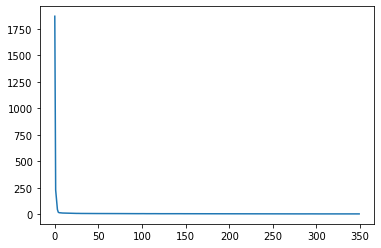

In [204]:
plt.plot(regressor.loss_curve_)

In [210]:
y_pred = regressor.predict(X)

In [212]:
np.sqrt(metrics.mean_squared_error(Y,y_pred))

2.9936255093548994

In [213]:
Y.stack().std()

35.422366083360785

In [214]:
Y.stack().mean()

171.08878452380952

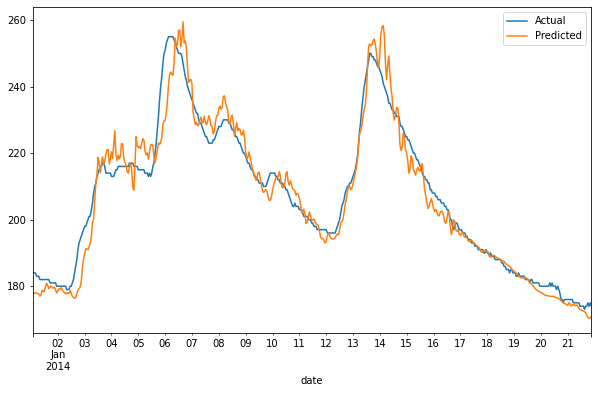

In [215]:
y_Pred = pd.DataFrame(y_pred, index=Y.index)

df_temp = pd.DataFrame({'Actual': Y[23], 'Predicted': y_Pred[23]})
df_temp = df_temp.head(500)
df_temp.plot(figsize=(10,6))

In [ ]:
 X_train, X_test, y_train, y_test = train_test_split(
     X, Y, test_size=0.2, random_state=42)

In [ ]:

# Set the parameters by cross-validation
tuned_parameters = [
    {"kernel": ["rbf"], "gamma": [1e-3, 1e-4], "C": [1, 10, 100, 1000]},
    {"kernel": ["linear"], "C": [1, 10, 100, 1000]},
]

scores = ["precision", "recall"]

for score in scores:
    print("# Tuning hyper-parameters for %s" % score)
    print()

    clf = GridSearchCV(SVC(), tuned_parameters, scoring="%s_macro" % score)
    clf.fit(X_train, y_train)

    print("Best parameters set found on development set:")
    print()
    print(clf.best_params_)
    print()
    print("Grid scores on development set:")
    print()
    means = clf.cv_results_["mean_test_score"]
    stds = clf.cv_results_["std_test_score"]
    for mean, std, params in zip(means, stds, clf.cv_results_["params"]):
        print("%0.3f (+/-%0.03f) for %r" % (mean, std * 2, params))
    print()

    print("Detailed classification report:")
    print()
    print("The model is trained on the full development set.")
    print("The scores are computed on the full evaluation set.")
    print()
    y_true, y_pred = y_test, clf.predict(X_test)
    print(classification_report(y_true, y_pred))
    print()

# Note the problem is too easy: the hyperparameter plateau is too flat and the
# output model is the same for precision and recall with ties in quality.